# P7: Select & reduce features

Keep the strong, drop the redundant. A CPP **signature** (from *P1: CPP signature*) is discriminative, but it is rarely *parsimonious*. It can hold hundreds of position-resolved physicochemical features, and neighbouring positions or correlated scales inside one AAontology category often say nearly the same thing. A raw numeric matrix (say, protein language model embedding dimensions) is just as redundant. This protocol shows how to reduce any labelled matrix `(X, y)` to a compact, **non-redundant** subset that still separates the **test group** (`label=1`) from the **reference group** (`label=0`). This reduction step sits *between* the two task classes of the pipeline: it takes the output of **determinant discovery** (the full signature from P1) and hands a compact input to **prediction** (the classifier in P8).

We stay at the **domain level** here (dataset prefix `DOM_`): the **unit of comparison** is the transmembrane-domain (TMD) **part** set, and the test group is γ-secretase **substrates** contrasted against **non-substrate** references.

*Keep the strong, drop the redundant.* Rank features by **effect size** (the magnitude of the adjusted AUC, `|AUC*|`, a feature's group-separating strength), then walk that ranking and discard any feature that merely echoes an already-kept, stronger one. Effect size **first**, then de-correlate: that order is the contract. What survives is the non-redundant core of the signature. The *recipe at a glance* figure below makes this concrete: features ranked by effect size, survivors highlighted, redundant echoes greyed out.

**When to use it.** Use this protocol once you already have a feature set or a numeric matrix and want a **compact, non-redundant** subset that still separates the two groups. The biological question is: *which* features actually carry the group-separating signal (which TMD/JMD physicochemical patterns, or which embedding dimensions) once near-duplicates have been removed?

Three mechanisms coexist in AAanalysis, and we walk all three:

- **Model-free** (univariate): rank each feature on its own effect size and prune correlated echoes. No classifier is fitted, the ranking *is* the basis. This is the CPP-style recipe that runs on *any* `(X, y)`.
- **Model-based**: let a fitted tree report which features it actually relied on, and keep those (`TreeModel.select_features`).
- **CPP-internal**: `CPP.run` already prunes redundancy while building the signature; you can tune and inspect that funnel directly.

**When *not* to use it.** Skip reduction while you are still *discovering* determinants and want the full signature for interpretation: that is P1's job, and pruning hides correlated members of a physicochemical family you may want to read. Skip it too if your matrix is already small and uncorrelated, or if your downstream model does its own regularisation and you are not after a human-readable shortlist.

**Input.** The input is **any** `(X, y)`: an `(n_samples, n_features)` numeric matrix `X` plus binary integer labels `y` (`1` = test, `0` = reference). Two sources appear below:

1. A **CPP feature matrix** produced upstream by *P1: CPP signature*. `SequenceFeature.feature_matrix` turns the signature `df_feat` + `df_parts` into `X`, keeping the per-feature metadata (`feature`, `category`, `abs_auc`, ...).
2. An **arbitrary user matrix** with no CPP metadata (e.g. protein language model embedding dimensions). Here you track surviving *column indices* instead of feature names.

Labels come from the `label` column of `df_seq` (`df_seq["label"].to_list()`), never from `len(df_seq)`: `load_dataset(..., n=N)` returns `2N` rows, N per class.

In [1]:
import aaanalysis as aa
import numpy as np
import matplotlib.pyplot as plt

aa.options["verbose"] = False
aa.options["random_state"] = 42

**Run.**

**A. Build the CPP feature matrix (upstream, from P1).** Split the sequences into parts, run `CPP` on the parts to obtain the signature, then materialise the numeric feature matrix `X` (see the CPP tutorial for the function details). We keep the fixtures small (`n=10`, giving 20 sequences) and `n_filter=50` so every cell stays well under the nbmake budget.

In [2]:
df_seq = aa.load_dataset(name="DOM_GSEC", n=10)   # 20 sequences: 10 substrates / 10 non-substrates
labels = df_seq["label"].to_list()

sf = aa.SequenceFeature()
df_parts = sf.get_df_parts(df_seq=df_seq)
cpp = aa.CPP(df_parts=df_parts)
df_feat = cpp.run(labels=labels, n_filter=50, n_jobs=1)

X = sf.feature_matrix(features=df_feat["feature"], df_parts=df_parts)
aa.display_df(df=df_feat[["feature", "abs_auc"]], n_rows=5)
X.shape

,feature,abs_auc
1,"JMD_N_TMD_N-Seg...,10)-ZIMJ680101",0.500000
2,"JMD_N_TMD_N-Pat...,12)-PALJ810110",0.470000
3,"TMD-Pattern(N,1...,11)-PALJ810110",0.470000
4,"TMD_C_JMD_C-Pat...,12)-TANS770105",0.470000
5,"TMD_C_JMD_C-Pat...,15)-AURR980102",0.465000


(20, 50)

**The model-free CPP-style recipe (four steps).** This is the recipe described above, made concrete:

1. **Effect size per feature**: `comp_auc_adjusted` returns the adjusted AUC (`AUC*`) for every column, in `[-0.5, 0.5]`. The sign is *direction* (which group is higher); the **strength** is the magnitude `|AUC*|`.
2. **Sort columns by `|AUC*|` descending**: strongest separators first.
3. **`NumericalFeature.filter_correlation` on the SORTED matrix.** This is **order-dependent**: it walks the columns left-to-right and keeps the **first** of each correlated pair, discarding any later column whose Pearson correlation with an already-kept one exceeds `max_cor`. Feeding it effect-sorted columns is therefore mandatory, this is the **sort-first contract**. On unsorted input it would keep arbitrary representatives.
4. **Take the top-n** of the survivors.

A few things to notice. The mask returned by `filter_correlation` can have **fewer** `True` entries than the requested `n`: pruning correlated echoes removes columns, so the kept set is capped at whatever survives, never padded back up. And `X` here is **already** redundancy-reduced: `CPP.run` in section A applied its own per-AAontology-category scale-correlation filter (default `max_cor=0.5`, `max_overlap=0.5`, `check_cat=True`). This model-free pass is *layered* on top of it, yet it still prunes a lot (even at the looser `max_cor=0.7`) because `filter_correlation` computes Pearson correlation on the actual feature-matrix **columns across all categories**, so it catches **cross-category echoes** that CPP's per-category filter never compares. The two filters see different redundancy, which is why a permissive second pass keeps shrinking an already-0.5-filtered set.

In [3]:
# 1) effect size, 2) effect-sorted column order
auc = aa.comp_auc_adjusted(X=X, labels=labels, n_jobs=1)
order = np.argsort(np.abs(auc), kind="stable")[::-1]  # stable: deterministic tie order

# 3) correlation filter on the EFFECT-SORTED matrix (sort-first contract)
nf = aa.NumericalFeature()
mask = nf.filter_correlation(X=X[:, order], max_cor=0.7)
kept = order[mask]          # original column indices, still in effect order

# 4) top-n of the non-redundant survivors
top_n = kept[:20]

# funnel: kept can be < n_features once correlated echoes are pruned (never padded up)
funnel = {"n_features": X.shape[1], "n_after_filter": int(mask.sum()), "n_top": len(top_n)}
aa.display_df(df=df_feat.iloc[top_n][["feature", "category", "abs_auc"]], n_rows=5)
funnel

,feature,category,abs_auc
1,"JMD_N_TMD_N-Seg...,10)-ZIMJ680101",Polarity,0.500000
4,"TMD_C_JMD_C-Pat...,12)-TANS770105",Conformation,0.470000
3,"TMD-Pattern(N,1...,11)-PALJ810110",Conformation,0.470000
6,"TMD_C_JMD_C-Pat...,14)-AURR980102",Conformation,0.465000
11,"TMD-Pattern(N,3...,15)-NAKH920108",Composition,0.455000


{'n_features': 50, 'n_after_filter': 10, 'n_top': 10}

**The recipe at a glance.** Here is the whole idea in one picture. Features are ranked left-to-right by effect size `|AUC*|`; the **kept** survivors are highlighted and the **dropped** redundant echoes greyed out. Notice how the de-correlation step does *not* simply take a prefix of the ranking: it keeps a strong feature, then skips every weaker feature correlated with it, so the survivors are spread across the ranking rather than bunched at the front.

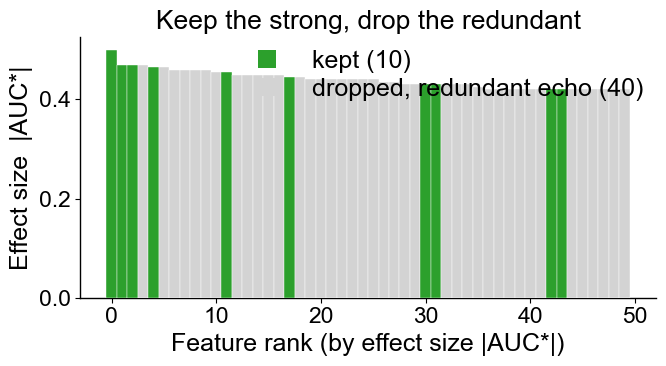

In [4]:
import seaborn as sns

# Effect-sorted bars: survivors highlighted, redundant echoes greyed out
abs_auc_sorted = np.abs(auc)[order]
n_keep = int(mask.sum())
n_drop = X.shape[1] - n_keep
c_keep, c_drop = "tab:green", "lightgray"
colors = [c_keep if m else c_drop for m in mask]

aa.plot_settings(weight_bold=False, short_ticks=True)
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(len(abs_auc_sorted)), abs_auc_sorted, color=colors,
       width=1.0, edgecolor="white", linewidth=0.3, zorder=3)
ax.set_xlabel("Feature rank (by effect size |AUC*|)")
ax.set_ylabel("Effect size  |AUC*|")
ax.set_title("Keep the strong, drop the redundant", size=aa.plot_gcfs() + 1)
sns.despine()

# tidy legend carrying the kept / dropped counts
dict_color = {f"kept ({n_keep})": c_keep,
              f"dropped, redundant echo ({n_drop})": c_drop}
aa.plot_legend(ax=ax, dict_color=dict_color, n_cols=1,
               loc="upper right", marker="s", marker_size=13)

plt.tight_layout()
plt.show()

**B. The same recipe on an arbitrary numeric matrix (embedding analog).** For a raw `(X, y)` with **no** CPP metadata (e.g. protein language model embedding dimensions), the identical four steps apply. (The matrix here is a deliberately synthetic stand-in for a real PLM-embedding matrix, with signal injected into known columns purely to make the kept-vs-dropped behaviour reproducible. It is *not* a recommended workflow input; in practice `X` would be real embeddings or a CPP feature matrix.) The only difference: you track surviving *column indices* rather than feature names. Below, columns **0 and 4** carry the separating signal, while columns **1 and 5** are noisier echoes of them: each echo shares its partner's noise (so they stay highly correlated) but carries only half the class shift (so its `|AUC*|` is clearly weaker). Within each correlated pair the sort-first filter keeps the **stronger original** (0 and 4, ranked first by effect size) and drops the **weaker echo** (1 and 5).

In [5]:
rng = np.random.default_rng(42)
Xe = rng.normal(size=(40, 12))
ye = np.array([0, 1] * 20)

# inject a separating signal into two dimensions (columns 0 and 4) ...
Xe[ye == 1, 0] += 1.5
Xe[ye == 1, 4] += 1.0
# ... then add echoes: columns 1 and 5 reuse each partner's noise (-> highly
# correlated) but carry only HALF the class shift (-> clearly weaker effect).
Xe[:, 1] = Xe[:, 0].copy(); Xe[ye == 1, 1] -= 0.75
Xe[:, 5] = Xe[:, 4].copy(); Xe[ye == 1, 5] -= 0.5

auc_e = aa.comp_auc_adjusted(X=Xe, labels=ye, n_jobs=1)
order_e = np.argsort(np.abs(auc_e), kind="stable")[::-1]
mask_e = nf.filter_correlation(X=Xe[:, order_e], max_cor=0.7)
kept_dims = order_e[mask_e]

# stronger originals 0 and 4 survive; their weaker echoes 1 and 5 are dropped
{"order": order_e.tolist(), "kept_dims": kept_dims.tolist()}

{'order': [0, 4, 1, 11, 6, 5, 2, 7, 10, 3, 8, 9],
 'kept_dims': [0, 4, 11, 6, 2, 7, 10, 3, 8, 9]}

**C. Alternative: model-based `TreeModel.select_features`.** When you have (or fit) a tree model, you can select by **learned importance** instead of univariate effect size. `TreeModel.fit` computes Monte-Carlo feature importances; `select_features` then row-filters `df_feat` by one `strategy` + one `param` knob (see the TreeModel tutorial for the function details):

- `'top_k'`: keep the `param` (int) features with the highest `feat_importance`.
- `'threshold'`: keep features with `feat_importance >= param` (float).
- `'frequency'`: keep features chosen in at least a `param` fraction of rounds; **requires** `fit(use_rfe=True)` (otherwise every round keeps all features, a no-op `RuntimeWarning`).

A selection that retains **no** features raises `ValueError` rather than returning an empty frame.

In [6]:
tm = aa.TreeModel()
# fit() computes feat_importance regardless of use_rfe; top_k/threshold use it
# directly. Only the frequency strategy needs use_rfe=True.
tm = tm.fit(X, labels=labels)
df_feat_imp = tm.add_feat_importance(df_feat=df_feat)
df_sel = tm.select_features(df_feat=df_feat_imp, strategy="top_k", param=15)

aa.display_df(df=df_sel[["feature", "feat_importance"]], n_rows=5)
df_sel.shape

,feature,feat_importance
1,"JMD_N_TMD_N-Seg...,10)-ZIMJ680101",3.206000
2,"JMD_N_TMD_N-Pat...,12)-PALJ810110",5.296000
3,"TMD-Pattern(N,1...,11)-PALJ810110",3.950000
4,"TMD_C_JMD_C-Pat...,12)-TANS770105",3.929000
5,"TMD_C_JMD_C-Pat...,15)-AURR980102",4.350000


(15, 15)

**D. Alternative: CPP's internal redundancy filter, inspecting the funnel.** `CPP.run` already performs redundancy reduction as part of the algorithm: it ranks candidates by effect size (`abs_auc`), then prunes by **position overlap** (`max_overlap`) and **correlation** (`max_cor`), optionally **per AAontology category** (`check_cat=True`). Because this greedy filter removes redundant features, `n_final` can be **fewer** than the requested `n_filter`: the requested number is a ceiling, not a guarantee. The cell below **inspects this funnel**: on this tiny fixture the tight `max_cor=0.3` / `max_overlap=0.3` still admit enough features to fill the ceiling, so it makes the *stages* visible rather than a shortfall. (The genuine sub-ceiling shortfall is shown in the model-free path above, where 50 features drop to far fewer.)

The funnel is exposed via `return_stats=True` (also stashed in `df_feat.attrs["last_filter_stats"]` and on `cpp.last_filter_stats_`): `n_candidates`, `n_after_prefilter`, `n_after_redundancy`, `n_final`. A genuine shortfall is surfaced as a `RuntimeWarning`. To retain more features, raise `max_cor` / `max_overlap` (admitting more redundancy).

In [7]:
df_feat2, stats = cpp.run(
    labels=labels, n_filter=50,
    max_cor=0.3, max_overlap=0.3, check_cat=True,
    return_stats=True, n_jobs=1,
)
# n_final (== len(df_feat2)) can be < the requested n_filter
{**stats, "len_df_feat2": len(df_feat2)}

{'n_candidates': 580140,
 'n_after_prefilter': 29007,
 'n_after_redundancy': 50,
 'n_final': 50,
 'len_df_feat2': 50}

**Output.** Each path yields a non-redundant subset, in a shape that matches its basis:

| Path | Returns | Shape note |
| --- | --- | --- |
| Model-free recipe | array of kept column indices (`kept`) / top-n (`top_n`); names via `df_feat.iloc[top_n]` | `len(kept)` can be `< n_features` |
| `TreeModel.select_features` | row-filtered `df_feat` (index reset) | `<= len(df_feat)` rows |
| CPP redundancy filter | `df_feat` already capped at `<= n_filter`, plus the funnel `stats` dict | `n_final <= n_filter` |

The model-free recipe is the only one that runs on a **bare** `(X, y)` with no feature metadata.

**How to interpret.**

| Mechanism | Basis | Input it needs | Knob | When to use | Gotcha |
| --- | --- | --- | --- | --- | --- |
| `filter_correlation` | univariate, model-free | any `(X, y)`; columns **must be effect-sorted** | `max_cor` | a bare matrix, or you trust effect size over a model | sort-first contract; can return `< n` |
| `TreeModel.select_features` | learned model importance | fitted `TreeModel` + `df_feat` | `strategy` + `param` | you have / want a classifier in the loop | `'frequency'` needs `fit(use_rfe=True)`; empty selection raises |
| CPP redundancy filter | `abs_auc` + overlap + correlation | sequences -> `CPP.run` | `n_filter`, `max_cor`, `max_overlap`, `check_cat` | building the signature itself | `n_final` can be `< n_filter` |

**Biological reading.** The survivors are the *non-redundant determinants* of the test group: the distinct physicochemical patterns (or embedding directions) that separate substrates from non-substrates, with each correlated family represented by its single strongest member rather than a cloud of near-duplicates.

**Key takeaways**

- **Effect size first, de-correlate second.** Rank by `|AUC*|`, then prune correlated echoes: the *sort-first contract* is what makes `filter_correlation` keep the strong representative of each family instead of an arbitrary one.
- **Fewer is the rule, not a bug.** Both `filter_correlation` and `CPP.run` can return fewer features than you asked for; the requested `n` is a ceiling. Raise `max_cor` / `max_overlap` to keep more.
- **Three filters see different redundancy.** Univariate correlation, learned tree importance, and CPP's per-category filter prune on different signals, so layering them shrinks an already-reduced set further.

**Common mistakes.**

- **Calling `filter_correlation` on unsorted columns**: it keeps the *first* of each correlated pair, so unsorted input keeps arbitrary (possibly weak) representatives. Always sort by `|AUC*|` first (the sort-first contract).
- **Expecting exactly `n` features back**: both `filter_correlation` and `CPP.run` can return **fewer** than requested once redundant features are pruned. Raise `max_cor` / `max_overlap` to retain more, or inspect the funnel (`return_stats=True` / `df_feat.attrs["last_filter_stats"]`).
- **Treating `AUC*` sign as strength**: the sign is *direction* (which group is higher); the effect size is the magnitude `|AUC*|`. Sort on the absolute value.
- **Wrong label coding**: `comp_auc_adjusted` needs exactly two integer classes (test=1, reference=0); pass them explicitly via `label_test` / `label_ref` if they differ.
- **Using `strategy='frequency'` without `fit(use_rfe=True)`**: it then keeps every feature (a no-op) and warns.

**Next step.** Feed the reduced, non-redundant feature set into **P8: Classifier**, where the compact subset becomes the input matrix for a `TreeModel` and is evaluated with repeated cross-validation.